In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv("./final.csv")
df.head(5)

,Name,Attendance (%),Study Hours/Week,Previous Score,Extracurricular Activities,Final Score
0,Jane Smith,68.73,15.44,83.71,Low,65.07
1,Chris Jones,97.54,13.50,67.65,High,56.83
2,Emily Williams,86.60,15.46,71.73,Low,61.53
3,Jane Moore,79.93,5.06,67.09,High,56.21
4,Jane Taylor,57.80,13.90,50.74,High,37.17


In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.head(5)

,name,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
0,Jane Smith,68.73,15.44,83.71,Low,65.07
1,Chris Jones,97.54,13.50,67.65,High,56.83
2,Emily Williams,86.60,15.46,71.73,Low,61.53
3,Jane Moore,79.93,5.06,67.09,High,56.21
4,Jane Taylor,57.80,13.90,50.74,High,37.17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        324 non-null    object 
 1   attendance_(%)              324 non-null    float64
 2   study_hours/week            324 non-null    float64
 3   previous_score              324 non-null    float64
 4   extracurricular_activities  324 non-null    object 
 5   final_score                 324 non-null    float64
dtypes: float64(4), object(2)
memory usage: 15.3+ KB


In [7]:
print(df.isnull().sum())

name                          0
attendance_(%)                0
study_hours/week              0
previous_score                0
extracurricular_activities    0
final_score                   0
dtype: int64


In [8]:
label_encoder = LabelEncoder()
df['extracurricular_activities'] = label_encoder.fit_transform(df['extracurricular_activities'])
df.head(5)

,name,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
0,Jane Smith,68.73,15.44,83.71,1,65.07
1,Chris Jones,97.54,13.50,67.65,0,56.83
2,Emily Williams,86.60,15.46,71.73,1,61.53
3,Jane Moore,79.93,5.06,67.09,0,56.21
4,Jane Taylor,57.80,13.90,50.74,0,37.17


In [9]:
df.describe()

,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
count,324.000000,324.000000,324.000000,324.000000,324.000000
mean,72.470185,15.413642,73.908796,1.040123,56.284599
std,13.273268,3.109443,12.122704,0.841049,8.773223
min,50.280000,5.060000,40.850000,0.000000,28.560000
25%,60.635000,13.497500,65.927500,0.000000,50.130000
50%,69.030000,15.340000,75.865000,1.000000,56.315000
75%,85.880000,17.235000,82.977500,2.000000,62.675000
max,99.340000,27.320000,94.450000,2.000000,74.530000


In [10]:
df.head()

,name,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
0,Jane Smith,68.73,15.44,83.71,1,65.07
1,Chris Jones,97.54,13.50,67.65,0,56.83
2,Emily Williams,86.60,15.46,71.73,1,61.53
3,Jane Moore,79.93,5.06,67.09,0,56.21
4,Jane Taylor,57.80,13.90,50.74,0,37.17


In [17]:
df.drop('name', axis=1)

,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
0,68.73,15.44,83.71,1,65.07
1,97.54,13.50,67.65,0,56.83
2,86.60,15.46,71.73,1,61.53
3,79.93,5.06,67.09,0,56.21
4,57.80,13.90,50.74,0,37.17
...,...,...,...,...,...
319,60.44,17.46,62.11,0,45.11
320,92.91,14.15,90.23,2,72.71
321,67.91,16.97,76.92,2,58.91
322,66.32,13.72,69.34,1,53.99


In [21]:
print(df.dtypes)

attendance_(%)                float64
study_hours/week              float64
previous_score                float64
extracurricular_activities      int64
final_score                   float64
dtype: object


<Axes: xlabel='previous_score', ylabel='final_score'>

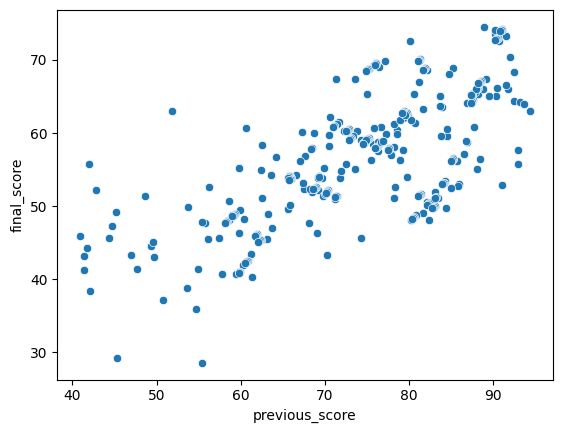

In [22]:
sns.scatterplot(x="previous_score",y="final_score",data=df)

The scatterplot between previous_score and final_score shows that they are not too much linearly realted to each other which means that the current performance of the students doesn't rely greatly on the previous performance.

<Axes: >

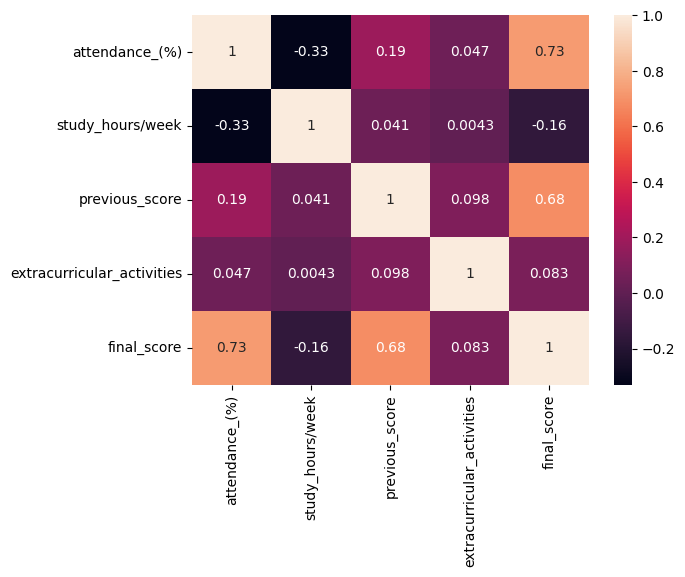

In [27]:
corr_mat = df.corr()
sns.heatmap(corr_mat,annot=True)

From the analysis of heatmap, it was found that attendance and study_hours/week showed negative correlation which indicated that dtudents not attending the college study more than the students attending the college at their home. However, it's surprising to notice that study_hours and final_score had a negative correlation which might indicate that study_hours/week maynot be measured in a good way.